TEE1～6、bootstrapなし

Using p range: [0.750000, 0.900000]  (N=16)


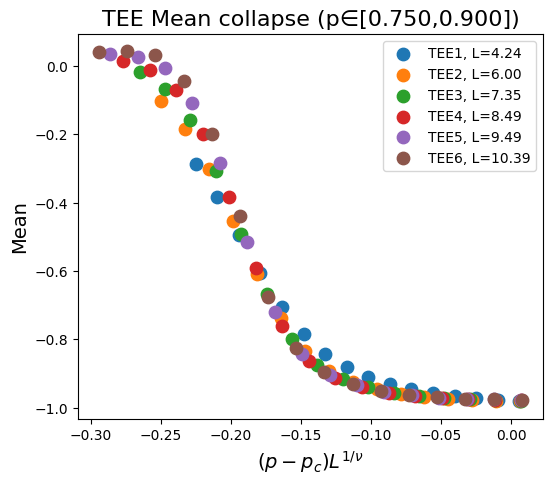

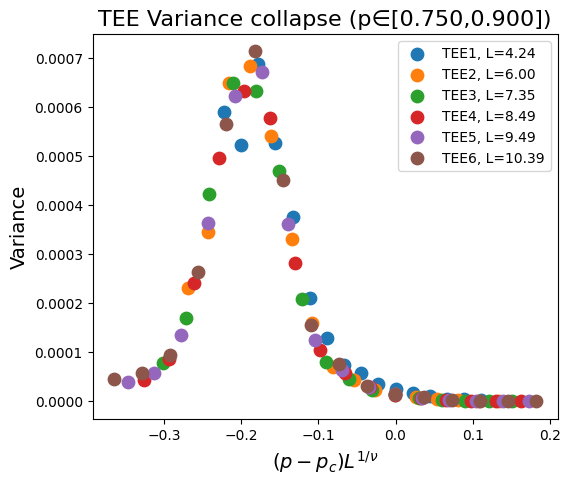

=== 平均 FSS ===
pc = 0.8962006522549949 ± 0.035021281208208015
nu = 3.3494311277736974 ± 0.7546784260340571
zeta = 0.032480737128606614 ± 0.05878963823685024
S (mean) = 691.5716542384233

=== 分散 FSS ===
pc = 0.8500212344744892 ± 0.020112564305593942
nu = 1.8070175417850738 ± 0.5181114472639429
zeta = 2.6185800406711275 ± 0.8771035980513467
S (var)  = 0.06648799833876338


In [56]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.75, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.84, nu0=1.7, zeta0=2.5)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.845, nu0=1.574, zeta0=3) #=========================================rho_c0=0.84, nu0=1.57, zeta0=2.9
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

Using p range: [0.750000, 0.900000]  (N=16)


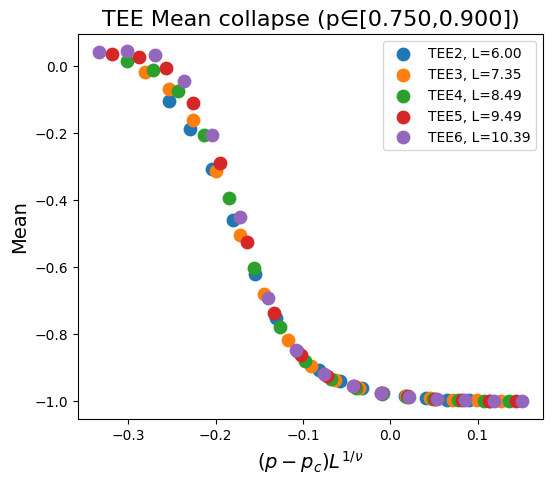

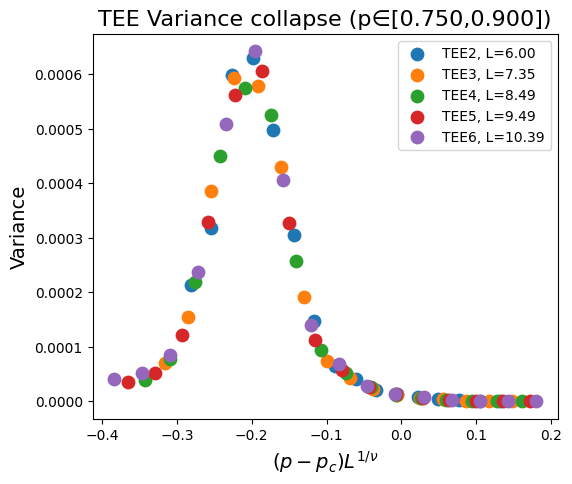

=== 平均 FSS ===
pc = 0.8533355297213872 ± 0.04066309378724813
nu = 1.9980793269227863 ± 1.0385196442811564
zeta = -0.002977181567123047 ± 0.030121078476214157
S (mean) = 176.98400193757138

=== 分散 FSS ===
pc = 0.852126639354692 ± 0.07387753567953428
nu = 1.766495520559246 ± 2.2742602962581375
zeta = 2.638034837505087 ± 2.186463556856389
S (var)  = 0.05407240657817526


In [9]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.75, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.85, nu0=1.67, zeta0=2.0)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

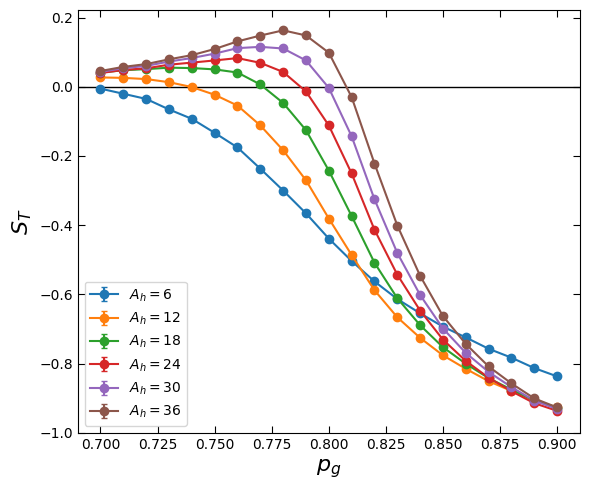

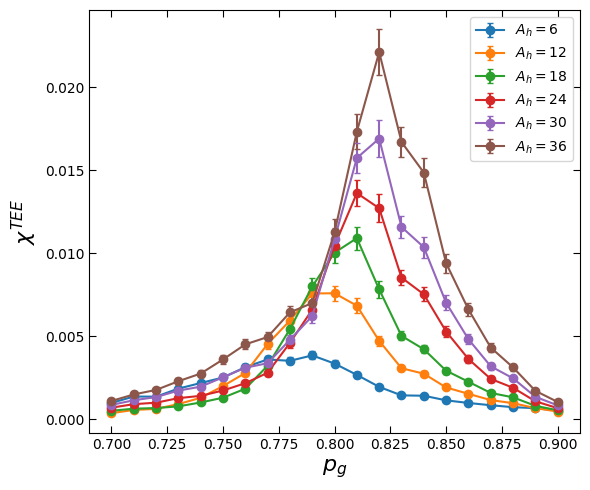

In [12]:
# ave/var を誤差つきで可視化（凡例は *_size）
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = "TEE_merged.npz"   # ここをあなたのファイルに
SERIES   = [1, 2, 3, 4, 5, 6] # 描きたい TEE 番号

z  = np.load(NPZ_PATH)
pg = z["pg"].astype(float)

def get(key):  # 存在チェックつき取得
    if key not in z:
        raise KeyError(f"'{key}' が {NPZ_PATH} にありません")
    return z[key].astype(float)


labels = [r"$A_h=6$", "$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

# SERIES と labels の対応を作る（順番対応）
if len(labels) < len(SERIES):
    raise ValueError("labels の数が SERIES より少ないです。対応する分だけ用意してください。")
label_map = {s: labels[idx] for idx, s in enumerate(SERIES)}

# --- ave ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    ave    = get(f"TEE{i}_ave")
    aveerr = get(f"TEE{i}_ave_err")
    ax.errorbar(pg, ave, yerr=aveerr, fmt='o-', capsize=2, label=label_map[i])

ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$S_{T}$",fontsize=16)
#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.axhline(y=0, color='k', lw=1)
ax.set_ylim(-1)
fig.tight_layout()
fig.savefig("TEE_ave_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


# --- var ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    var    = get(f"TEE{i}_var")
    varerr = get(f"TEE{i}_var_err")
    if len(var) != len(pg) or len(varerr) != len(pg):
        raise ValueError(f"TEE{i} の長さが pg と一致しません")
    ax.errorbar(pg, var, yerr=varerr, fmt='o-', capsize=2, label=label_map[i])
ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$\chi^{TEE}$",fontsize=16)

#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)

fig.tight_layout()
fig.savefig("TEE_var_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


[coarse] pc0=0.833060, nu0=1.2800, S=5.0524
TEE1-6(参考)

=== Variance FSS (fss_merged.npz) ===
['4.24', '6.00', '7.35', '8.49', '9.49', '10.39']
pc   = 0.837106634 ± 0.002996550
nu   = 1.509822900 ± 0.306673561
zeta = 2.478388141 ± nan
S     = 4.197396


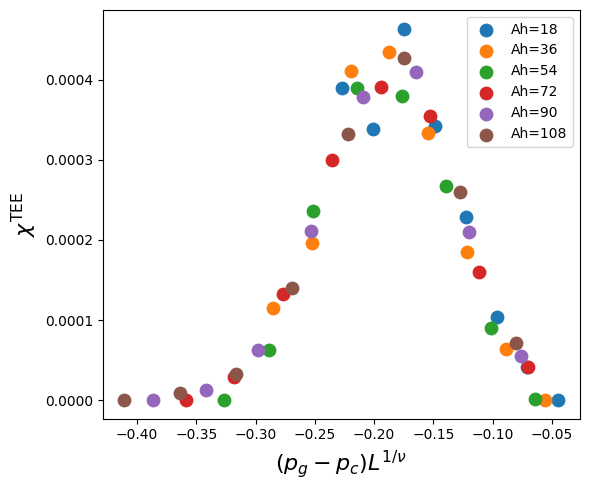

In [39]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import fssa
from scipy.optimize import curve_fit

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"

# --- L は √Ah（あなたの指定） ---
AH = {1:18, 2:36, 3:54, 4:72, 5:90, 6:108}

# まずは補正の効きやすい小サイズを外して安定化
TEE_cols = [1,2,3,4,5,6]        # ← 成功したら [2,3,4,5,6] に戻す
L_list   = [np.sqrt(AH[c]) for c in TEE_cols]

# ζを固定（ピーク高さの独立推定 ≈ 1.83 を採用）
FIX_ZETA = False
ZETA_VAL = 3.4

# 誤差フロア（過大にしない）
ERR_FLOOR_REL = 1e-4

# コラプスの |x| 窓（描画時）
S_WINDOW = 2.0

# ======================
# データ読み込み（Var とそのSE）
# ======================
dat = np.load(npz_path, allow_pickle=True)
pg = np.asarray(dat["pg"], float)

def k(c, suf): return f"TEE{c}_{suf}"
A  = np.array([dat[k(c,"var")]     for c in TEE_cols], float)  # shape=(nL,nP)
dA = np.array([dat[k(c,"var_err")] for c in TEE_cols], float)

# ======================
# 放物線で各サイズの g*_L を推定 → 左右対称の p 窓を決定
# ======================
def quad(x,a,b,c): return a*x**2 + b*x + c
def gstar_parabola(pg,y,dy):
    eps = max(1e-12, np.nanmedian(np.abs(y))*1e-6)
    dy  = np.where((dy>0)&np.isfinite(dy), dy, eps)
    i   = int(np.nanargmax(y))
    lo,hi = max(0,i-2), min(len(pg), i+3)
    x,yy,dyy = pg[lo:hi], y[lo:hi], dy[lo:hi]
    if len(x) < 3: return pg[i]
    (Aq,Bq,Cq),_ = curve_fit(quad, x, yy, sigma=dyy, absolute_sigma=True, maxfev=20000)
    gx = -Bq/(2*Aq)
    return gx if (pg.min() <= gx <= pg.max()) else pg[i]

gstars = np.array([gstar_parabola(pg, A[i], dA[i]) for i in range(len(TEE_cols))])
pc_center = float(gstars.mean())
dpg = max(0.04, float(gstars.std()) + 0.02)     # ← 肩が両側入る幅
mask = (pg >= pc_center - dpg) & (pg <= pc_center + dpg)

# 窓で切って昇順に並び替え
pg_use = pg[mask]; order = np.argsort(pg_use)
pg_use = pg_use[order]
A_use  = A[:,  mask][:, order]
dA_use = dA[:, mask][:, order]

# （任意）基線オフセット除去：窓内で最小値を引くと S が改善する系がある
A_base = A_use.min(axis=1, keepdims=True)
A_use  = A_use - A_base

# 誤差フロア（控えめに）
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(A_use))
dA_use = np.maximum(dA_use, eps)

# ======================
# 粗探索 → autoscale（ζ固定）
# ======================
ZETA = ZETA_VAL if FIX_ZETA else 2.0
rhos = np.linspace(pc_center-0.03, pc_center+0.05, 33)
nus  = np.linspace(1.0, 2.2, 31)

bestS, rho0, nu0 = np.inf, None, None
for rh in rhos:
    for nv in nus:
        xs, ys, dys = fssa.scaledata(L_list, pg_use, A_use, dA_use, rh, nv, ZETA)
        S = fssa.quality(xs, ys, dys)
        if np.isfinite(S) and S < bestS:
            bestS, rho0, nu0 = S, rh, nv
print(f"[coarse] pc0={rho0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")
print("TEE1-6(参考)")

ret = fssa.autoscale(L_list, pg_use, A_use, dA_use,
                     rho_c0=rho0, nu0=nu0, zeta0=ZETA)
if FIX_ZETA:
    ret.zeta  = ZETA
    ret.dzeta = 0.0

# スケール変換（コラプス座標）と評価関数
xs, ys, dys = fssa.scaledata(L_list, pg_use, A_use, dA_use,
                             ret.rho, ret.nu, ret.zeta)
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS (fss_merged.npz) ===")
print([f"{L:.2f}" for L in L_list])
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")

# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    #ax.plot(xs.T[:, i], ys.T[:, i], 'o', label=f"Ah={int(AH[TEE_cols[i]])}")
    ax.scatter(xs.T[:, i], ys.T[:, i],
           label=f"Ah={int(AH[TEE_cols[i]])}", s=80)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{\rm TEE}$",fontsize=16)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches='tight')
plt.show()


TEE1-6(参考)


=== Variance FSS===
TEE1-6 [4.242640687119285, 6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.840679757 ± 0.003168940
nu   = 1.564091391 ± 0.347137373
zeta = 2.220113616 ± 0.687105895
S     = 4.424699


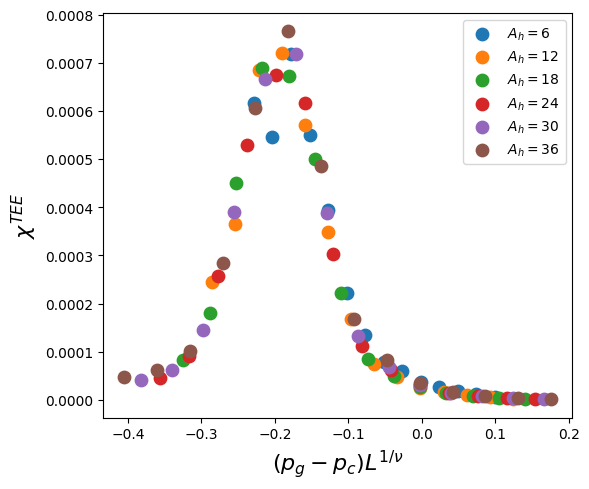

In [45]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#L_list   = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
TEE_cols = [1, 2, 3, 4, 5, 6]  # = TEE1..TEE6 を使う例
#TEE_cols = [3, 4, 5, 6]  # = TEE3..TEE6 を使う例


# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.75
pc_max = 0.88

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 3.6
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
#zeta0    = 3.78


rho_c0, nu0, zeta0 = 0.87, 1.71, 2.9

#Best
#pc_min = 0.75
#pc_max = 0.89
#rho_c0, nu0,zeta0 = 0.87, 1.74
#zeta0 = 3.78 (False) 
#pc   = 0.890030137 ± 0.005939050
#nu   = 1.761236425 ± 0.093202186
#zeta = 3.626721887 ± 0.703192104
#S     = 4.571723


# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
"""rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv

print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")"""

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS===")
print("TEE1-6",L_list)
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=6$", r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
#labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    #ax.plot(xs.T[:, i], ys.T[:, i],'o',label=label, alpha=0.9)
    ax.scatter(xs.T[:, i], ys.T[:, i],label=label, s=80)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


[coarse] pc0=0.865000, nu0=2.3931, S=2.6433

=== Variance FSS===
TEE2-6 [6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.851992065 ± 0.015583180
nu   = 1.791075001 ± 0.581281110
zeta = 2.644298749 ± nan
S     = 1.692736


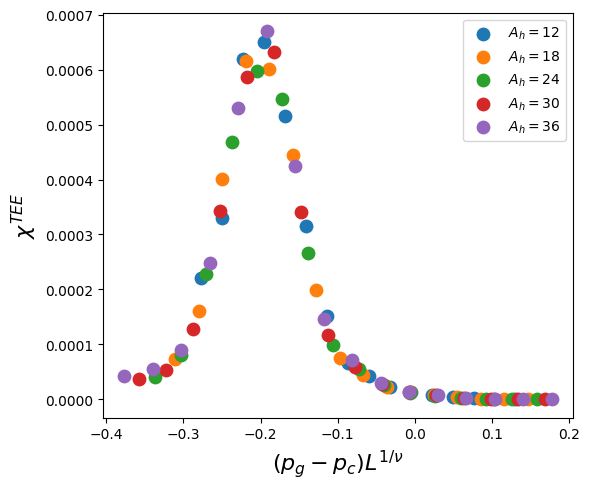

In [46]:





#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
#L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
#TEE_cols = [1, 2, 3, 4, 5, 6]  # = TEE1..TEE6 を使う例
TEE_cols = [2,3, 4, 5, 6]  # = TEE3..TEE6 を使う例

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 3.58
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 3.7

# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.75
pc_max = 0.9
rho_c0, nu0, zeta0 = 0.85, 1.74, 3.68



#Best
#pc_min = 0.75
#pc_max = 0.89
#rho_c0, nu0,zeta0 = 0.87, 1.74
#zeta0 = 3.78 (False) 
#pc   = 0.890030137 ± 0.005939050
#nu   = 1.761236425 ± 0.093202186
#zeta = 3.626721887 ± 0.703192104
#S     = 4.571723

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv

print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS===")
print("TEE2-6",L_list)
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
#labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    #ax.plot(xs.T[:, i], ys.T[:, i],'o', label=label, alpha=0.9)
    ax.scatter(xs.T[:, i], ys.T[:, i],label=label, s=80)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
#L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
#TEE_cols = [1, 2, 3, 4, 5, 6]  # = TEE1..TEE6 を使う例
TEE_cols = [2,3, 4, 5, 6]  # = TEE3..TEE6 を使う例

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 3.58
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 3.7

# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.75
pc_max = 0.9
rho_c0, nu0, zeta0 = 0.87, 1.74, 3.68

=== Variance FSS===
TEE2-6 [6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.876154306 ± 0.048171491
nu   = 1.742180939 ± 0.292021139
zeta = 3.759018744 ± 1.072767981
S     = 4.833594

たぶんこれがベスト2025/10/18

In [46]:
!pwd

/home/kataoka/TC_stabilizer_test/FSS/px_0/TEE/px_0.7/TEE2-6
